Implement Scaled Dot-Product Attention and a Mini Transformer Encoder 
You are required to implement the core components of the Transformer architecture 
using PyTorch. The assignment focuses on understanding how attention works inside a 
Transformer. 
Problem Statement 
Implement a simple Transformer Encoder from scratch and test it on a small text 
classification task. 

You should implement the following: 
1. Scaled Dot-Product Attention  
2. Multi-Head Self-Attention  
3. Positional Encoding  
4. Feed Forward Network  
5. Transformer Encoder Block  
6. A simple classifier using the Transformer Encoder  

Dataset 
Use any small dataset, such as:

• IMDB small subset  
• AG News subset  
• SMS Spam Detection dataset  
• A custom dataset with 2 classes, for example positive/negative sentences  

You may also create a small toy dataset manually.

<div align="center">
----------------------------------------------------------------------------------------------XXXXXXXXXXXXXXXXXXXXXX----------------------------------------------------------------------------------------------
</div>

In [19]:
# import kagglehub
# path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
# print("Path to dataset files:", path)

In [107]:
#import necessary libraries
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [30]:
DATASET_PATH = r'D:\machine_learning\datasets\sms_spam_detection'
df = pd.read_csv(DATASET_PATH + '\spam.csv', encoding='latin-1') #utf-8 is failing for some reason. okay there is something wrong in row number 2, escape character probably
display(df)

df = df[['v1', 'v2']] 
df.columns = ['label', 'text']

# replacing labels with 1 and 0, with spam being 1 and ham being 0
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# final dataset for training/testing
display(df)

<>:2: SyntaxWarning: invalid escape sequence '\s'
,<>:2: SyntaxWarning: invalid escape sequence '\s'
,C:\Users\Sumed\AppData\Local\Temp\ipykernel_10452\2225014558.py:2: SyntaxWarning: invalid escape sequence '\s'
,  df = pd.read_csv(DATASET_PATH + '\spam.csv', encoding='latin-1') #utf-8 is failing for some reason. okay there is something wrong in row number 2, escape character probably


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


TASK 1

Preprocess the text data:  
o Tokenize sentences  
o Convert words into integer IDs  
o Pad sequences to the same length

In [52]:
#part a - Tokenize Sentences

#tokenizing process
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) #removing special characters and punctuation to simplify vocabulary
    return text.split()
df['tokens'] = df['text'].apply(tokenize) # apply for each row of the dataframe
display(df[['text', 'tokens']])

,text,tokens
0,"Go until jurong point, crazy.. Available only ...","[go, until, jurong, point, crazy, available, o..."
1,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,U dun say so early hor... U c already then say...,"[u, dun, say, so, early, hor, u, c, already, t..."
4,"Nah I don't think he goes to usf, he lives aro...","[nah, i, dont, think, he, goes, to, usf, he, l..."
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,"[this, is, the, 2nd, time, we, have, tried, 2,..."
5568,Will Ì_ b going to esplanade fr home?,"[will, b, going, to, esplanade, fr, home]"
5569,"Pity, * was in mood for that. So...any other s...","[pity, was, in, mood, for, that, soany, other,..."
5570,The guy did some bitching but I acted like i'd...,"[the, guy, did, some, bitching, but, i, acted,..."


In [54]:
#part b - Convert words into integer IDs

word_counter = Counter()
for tokens in df['tokens']:
    word_counter.update(tokens)

# create vocabulary
vocab = {'<PAD>': 0
        ,'<UNK>': 1
        }

# assign integer IDs
for word in word_counter:
    vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab)) #13498

# we do this because transformers require equal sequence lengths
def tokens_to_ids(tokens, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in tokens]

df['input_ids'] = df['tokens'].apply(lambda x: tokens_to_ids(x, vocab))

display(df[['tokens', 'input_ids']])

Vocabulary Size: 9479


,tokens,input_ids
0,"[go, until, jurong, point, crazy, available, o...","[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1..."
1,"[ok, lar, joking, wif, u, oni]","[22, 23, 24, 25, 26, 27]"
2,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[28, 29, 9, 30, 31, 32, 33, 34, 35, 36, 37, 38..."
3,"[u, dun, say, so, early, hor, u, c, already, t...","[26, 51, 52, 53, 54, 55, 26, 56, 57, 58, 52]"
4,"[nah, i, dont, think, he, goes, to, usf, he, l...","[59, 60, 61, 62, 63, 64, 34, 65, 63, 66, 67, 6..."
...,...,...
5567,"[this, is, the, 2nd, time, we, have, tried, 2,...","[171, 101, 155, 399, 477, 369, 132, 436, 30, 8..."
5568,"[will, b, going, to, esplanade, fr, home]","[222, 261, 278, 34, 1970, 1339, 166]"
5569,"[pity, was, in, mood, for, that, soany, other,...","[9475, 358, 9, 5535, 88, 276, 9476, 1391, 9477]"
5570,"[the, guy, did, some, bitching, but, i, acted,...","[155, 2922, 250, 84, 9478, 368, 60, 8571, 83, ..."


In [51]:
#part c - pad sequences to the same length

#decide max length
df['length'] = df['input_ids'].apply(len)
print(df['length'].describe())


#most messages are short in length, keeping max_len as 20, might change later
MAX_LEN = 20
def pad_sequence(sequence, max_len):
    if len(sequence) < max_len:
        sequence = sequence + [0] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    return sequence

df['padded_input_ids'] = df['input_ids'].apply(lambda x: pad_sequence(x, MAX_LEN))

display(df[['input_ids', 'padded_input_ids']])

count    5572.000000
,mean       15.238514
,std        11.085235
,min         0.000000
,25%         7.000000
,50%        12.000000
,75%        22.000000
,max       171.000000
,Name: length, dtype: float64


,input_ids,padded_input_ids
0,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...","[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1..."
1,"[22, 23, 24, 25, 26, 27]","[22, 23, 24, 25, 26, 27, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[28, 29, 9, 30, 31, 32, 33, 34, 35, 36, 37, 38...","[28, 29, 9, 30, 31, 32, 33, 34, 35, 36, 37, 38..."
3,"[26, 51, 52, 53, 54, 55, 26, 56, 57, 58, 52]","[26, 51, 52, 53, 54, 55, 26, 56, 57, 58, 52, 0..."
4,"[59, 60, 61, 62, 63, 64, 34, 65, 63, 66, 67, 6...","[59, 60, 61, 62, 63, 64, 34, 65, 63, 66, 67, 6..."
...,...,...
5567,"[171, 101, 155, 399, 477, 369, 132, 436, 30, 8...","[171, 101, 155, 399, 477, 369, 132, 436, 30, 8..."
5568,"[222, 261, 278, 34, 1970, 1339, 166]","[222, 261, 278, 34, 1970, 1339, 166, 0, 0, 0, ..."
5569,"[9475, 358, 9, 5535, 88, 276, 9476, 1391, 9477]","[9475, 358, 9, 5535, 88, 276, 9476, 1391, 9477..."
5570,"[155, 2922, 250, 84, 9478, 368, 60, 8571, 83, ...","[155, 2922, 250, 84, 9478, 368, 60, 8571, 83, ..."


TASK 2

Implement Scaled Dot-Product Attention using the formula:  

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, Q, K, V):
        d_k = Q.size(-1) # dimension of key vectors
        scores = torch.matmul(Q, K.transpose(-2, -1)) # compute attention scores
        scores = scores / math.sqrt(d_k) # scale scores
        attention_weights = F.softmax(scores, dim=-1) # apply softmax
        output = torch.matmul(attention_weights, V) # weighted sum of values
        
        return output, attention_weights

Output Shape: torch.Size([2, 4, 8])
,Attention Weights Shape: torch.Size([2, 4, 4])


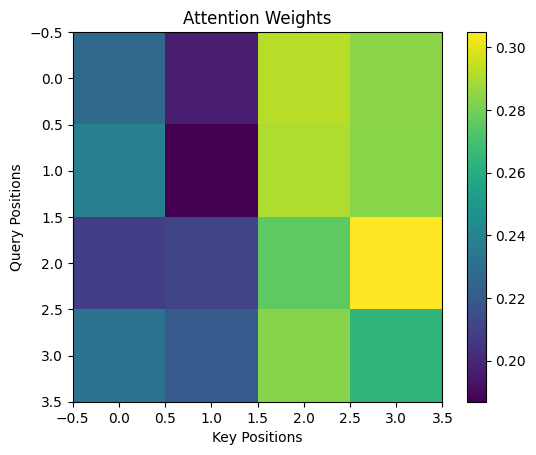

In [79]:
batch_size = 2
seq_len = 4
d_model = 8

Q = torch.rand(batch_size, seq_len, d_model)
K = torch.rand(batch_size, seq_len, d_model)
V = torch.rand(batch_size, seq_len, d_model)

attention = ScaledDotProductAttention()

output, weights = attention(Q, K, V)

print("Output Shape:", output.shape)
print("Attention Weights Shape:", weights.shape)

plt.imshow(weights[0].detach().numpy(), cmap='viridis')
plt.colorbar()
plt.title("Attention Weights")
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.show();

Scaled Dot-Product Attention computes relationships between all words in a sequence. The query and key vectors determine attention scores, which indicate how much focus should be given to different words. The scores are normalized using softmax and used to compute weighted combinations of value vectors. Scaling by √dk stabilizes gradients during training.

TASK 3 

Implement Multi-Head Attention by splitting the input into multiple heads. 

In [ ]:
# Single attention can only learn one type of relationship at a time.
# Multi-head attention allows the model to learn multiple relationships simultaneously.

class MultiHeadAttention(nn.Module):
    
    def __init__(self, d_model, num_heads):
        super().__init__()       
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        # linear projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # output projection
        self.W_o = nn.Linear(d_model, d_model)
        
        self.attention = ScaledDotProductAttention()
        
    def split_heads(self, x, batch_size):
        # reshape
        x = x.view(batch_size, -1, self.num_heads, self.head_dim)
        # transpose
        x = x.transpose(1, 2)
        return x
    
    def forward(self, x):
        batch_size = x.size(0)

        # generate Q, K, V
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)        
        # split into heads
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)
        
        # attention
        attention_output, attention_weights = self.attention(Q, K, V)
        
        # transpose back
        attention_output = attention_output.transpose(1, 2)
        
        # concatenate heads
        concat_output = attention_output.contiguous().view(
            batch_size,
            -1,
            self.d_model
        )
        
        # final linear layer
        output = self.W_o(concat_output)
        
        return output, attention_weights

In [81]:
batch_size = 2
seq_len = 5
d_model = 64
num_heads = 4

x = torch.rand(batch_size, seq_len, d_model)

mha = MultiHeadAttention(d_model, num_heads)

output, weights = mha(x)

print("Output Shape:", output.shape)
print("Attention Weights Shape:", weights.shape)

Output Shape: torch.Size([2, 5, 64])
,Attention Weights Shape: torch.Size([2, 4, 5, 5])


Multi-Head Attention improves the Transformer’s ability to learn different relationships between words by computing attention multiple times in parallel. The input embeddings are split into multiple heads, and each head independently learns contextual interactions. The outputs from all heads are concatenated and projected back into the original embedding dimension.

TASK 4

Add Positional Encoding to preserve word order information.  

In [ ]:
# Without positional encoding, Transformers do not understand word order.
# eg "lion ate deer" and "deer ate lion" although have different meaning but would appear the same if order is not preserved

class PositionalEncoding(nn.Module):
    
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        
        position = torch.arange(0, max_len).unsqueeze(1)
        
        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )
        
        # apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # add batch dimension
        pe = pe.unsqueeze(0)
        
        # register as buffer
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        
        seq_len = x.size(1)
        
        x = x + self.pe[:, :seq_len]
        
        return x

torch.Size([2, 10, 64])


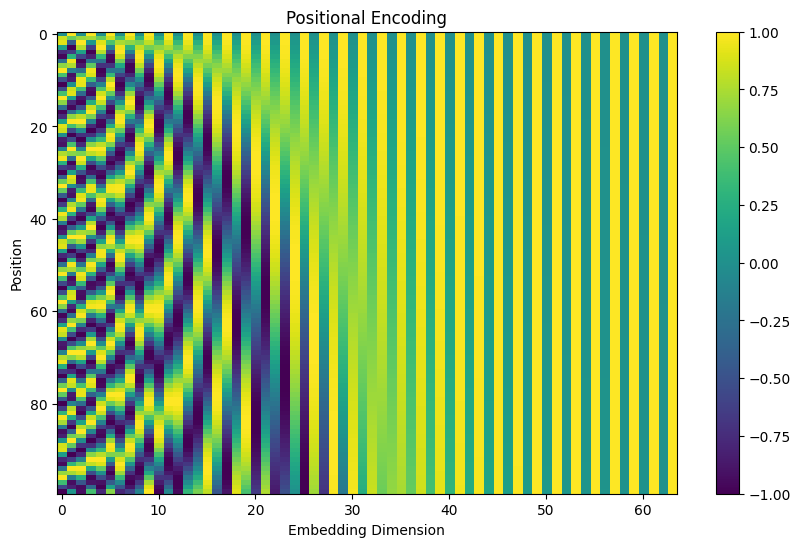

In [85]:
batch_size = 2
seq_len = 10
d_model = 64

x = torch.rand(batch_size, seq_len, d_model)

pos_encoder = PositionalEncoding(d_model)

output = pos_encoder(x)

print(output.shape)

pe_matrix = pos_encoder.pe[0].detach().numpy()

plt.figure(figsize=(10, 6))
plt.imshow(pe_matrix[:100], aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Positional Encoding")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.show();

TASK 5

Build one Transformer Encoder Block using:  
o Multi-head self-attention  
o Feed-forward layer  
o Residual connection  
o Layer normalization

In [86]:
class FeedForward(nn.Module):
    
    def __init__(self, d_model, d_ff):
        super().__init__()
        
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        
        return x

In [87]:
class TransformerEncoderBlock(nn.Module):
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        # multi-head attention
        self.attention = MultiHeadAttention(d_model, num_heads)
        
        # feed-forward network
        self.ffn = FeedForward(d_model, d_ff)
        
        # layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # dropout
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        
        attention_output, attention_weights = self.attention(x)
        
        # residual connection + normalization
        x = self.norm1(x + self.dropout(attention_output))
        
        ff_output = self.ffn(x)
        
        # residual connection + normalization
        output = self.norm2(x + self.dropout(ff_output))
        
        return output, attention_weights

In [88]:
batch_size = 2
seq_len = 10
d_model = 64
num_heads = 4
d_ff = 128

x = torch.rand(batch_size, seq_len, d_model)

encoder = TransformerEncoderBlock(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff
)

output, weights = encoder(x)

print("Output Shape:", output.shape)
print("Attention Shape:", weights.shape)

Output Shape: torch.Size([2, 10, 64])
,Attention Shape: torch.Size([2, 4, 10, 10])


TASK 6

Train the model for text classification.

In [95]:
X = torch.tensor(df['padded_input_ids'].tolist())
y = torch.tensor(df['label'].tolist())


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


class SpamDataset(Dataset):
    
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [99]:
BATCH_SIZE = 32

train_dataset = SpamDataset(X_train, y_train)
test_dataset = SpamDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

In [100]:
class TransformerClassifier(nn.Module):
    
    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        max_len,
        num_classes,
        dropout=0.1
    ):
        super().__init__()
        
        # embedding layer
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        # positional encoding
        self.positional_encoding = PositionalEncoding(
            d_model,
            max_len
        )
        
        # transformer encoder block
        self.encoder = TransformerEncoderBlock(
            d_model,
            num_heads,
            d_ff,
            dropout
        )
        
        # dropout
        self.dropout = nn.Dropout(dropout)
        
        # classifier
        self.fc = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        
        # embeddings
        x = self.embedding(x)
        
        # positional encoding
        x = self.positional_encoding(x)
        
        # encoder block
        x, attention_weights = self.encoder(x)
        
        # mean pooling
        x = x.mean(dim=1)
        
        # dropout
        x = self.dropout(x)
        
        # classification
        output = self.fc(x)
        
        return output, attention_weights

In [101]:
VOCAB_SIZE = len(vocab)

D_MODEL = 64
NUM_HEADS = 4
D_FF = 128
MAX_LEN = 20
NUM_CLASSES = 2


model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    num_classes=NUM_CLASSES
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device) #training on pascal gpu, blackwell on standby

model = model.to(device)

cuda


In [104]:
EPOCHS = 10

train_losses = []

for epoch in range(EPOCHS):
    
    model.train()
    
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # forward pass
        outputs, _ = model(batch_X)
        
        # loss
        loss = criterion(outputs, batch_y)
        
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    
    train_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Loss: {avg_loss:.4f}")

Epoch 1/10
,Loss: 0.2279
,Epoch 2/10
,Loss: 0.1126
,Epoch 3/10
,Loss: 0.0746
,Epoch 4/10
,Loss: 0.0509
,Epoch 5/10
,Loss: 0.0292
,Epoch 6/10
,Loss: 0.0194
,Epoch 7/10
,Loss: 0.0138
,Epoch 8/10
,Loss: 0.0087
,Epoch 9/10
,Loss: 0.0045
,Epoch 10/10
,Loss: 0.0025


In [105]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    
    for batch_X, batch_y in test_loader:
        
        batch_X = batch_X.to(device)
        
        outputs, _ = model(batch_X)
        
        preds = torch.argmax(outputs, dim=1)
        
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch_y.numpy())

TASK 7

Report:  
o Training loss  
o Accuracy  
o Example predictions  
o A short explanation of how attention helps the model  

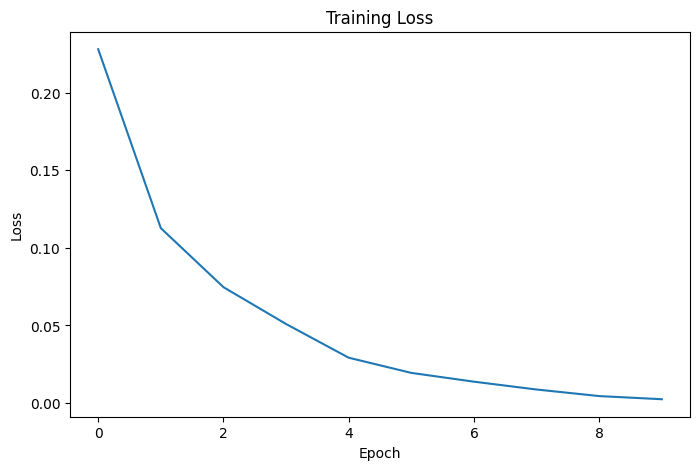

In [ ]:
# part a - training loss

plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show();

In [ ]:
# part b - accuracy

accuracy = accuracy_score(true_labels, predictions)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9713004484304932


In [154]:
# part c - example predictions

def predict(text):
    
    tokens = tokenize(text)
    
    token_ids = tokens_to_ids(tokens, vocab)
    
    padded = pad_sequence(token_ids, MAX_LEN)
    
    x = torch.tensor([padded]).to(device)
    
    model.eval()
    
    with torch.no_grad():
        
        output, _ = model(x)
        
        prediction = torch.argmax(output, dim=1).item()
    
    if prediction == 1:
        return "Spam"
    else:
        return "Ham"
    


print(
    predict(
        "your photos and videos will be removed, purchase subscription"
    )
)


print(
    predict(
        "congrats, you have won, deposit 1000 INR urgently to claim prize"
    )
)

print(
    predict(
        "Hey, are we meeting tomorrow?"
    )
)

print(
    predict(
        "this is the end"
    )
)

Spam
,Spam
,Ham
,Ham


part d - A short explanation of how attention helps the model  
Transformer encoder learned contextual relationships between words using self-attention. Mean pooling was applied to obtain sentence-level representations for classification.

## Transformer Model Architecture
This model follows a sequence-to-sequence classification pipeline to determine if a message is **Spam** or **Ham**.

---

### 1. Data Preprocessing
*   **Input Text**: Raw string data.
*   **Tokenization**: Breaking text into individual words or sub-word units.
*   **Integer Encoding**: Mapping tokens to unique numerical IDs.
*   **Padding**: Ensuring all sequences in a batch have the same length.

### 2. Feature Representation
*   **Embedding Layer**: Maps integer IDs into dense continuous vectors.
*   **Positional Encoding**: Adds information about the order of words since Transformers have no inherent sense of sequence.

### 3. Core Processing
> **Transformer Encoder Block**: Processes the sequence using **Scaled Dot-Product Attention** and Feed-Forward networks.

### 4. Classification Head
*   **Mean Pooling**: Reduces the sequence of hidden states into a single vector by averaging.
*   **Linear Classification Layer**: A fully connected layer that maps the features to class logits.
*   **Spam/Ham Prediction**: The final output via a Sigmoid or Softmax function.

Below is a pictorial simplified architecture diagram of the implemented Transformer with attention mechanism

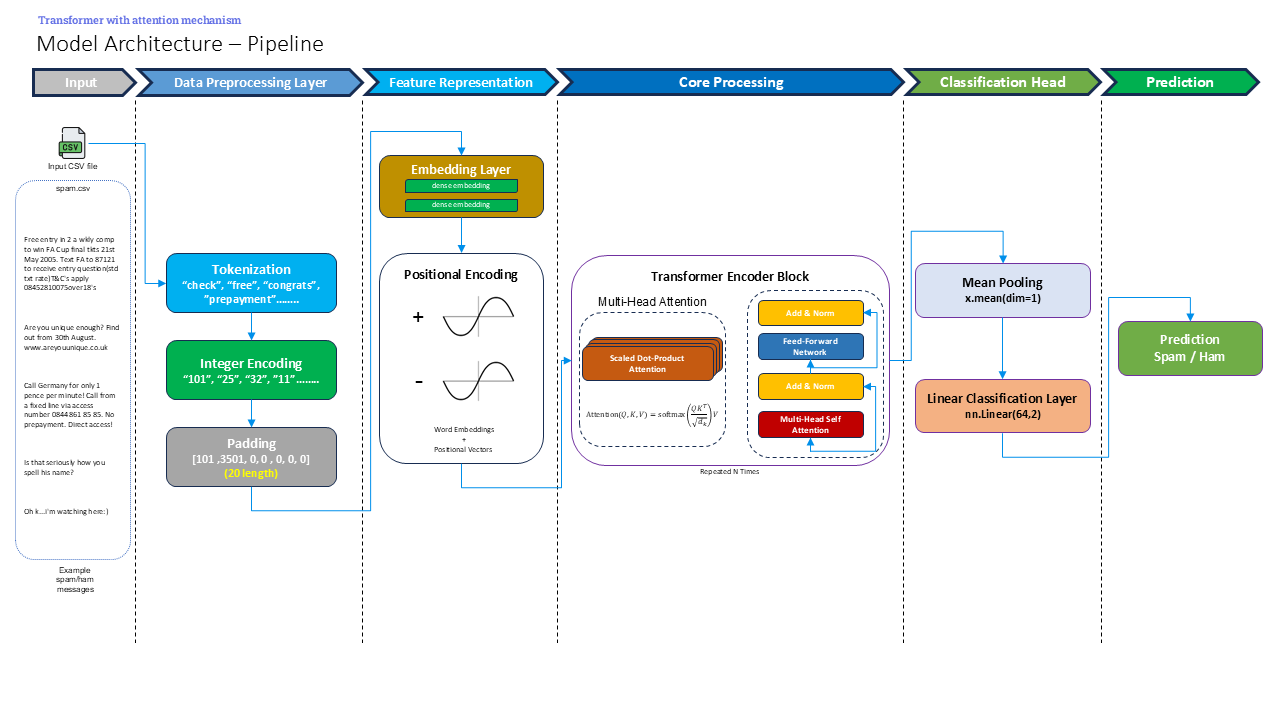